# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset: https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017?select=goalscorers.csv

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [103]:
former_names = pd.read_csv('former_names.csv')
goal_scorers = pd.read_csv('goalscorers.csv')
results = pd.read_csv('results.csv')
shootouts = pd.read_csv('shootouts.csv')

## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

# *former_names*

In [104]:
former_names.info()
#the smallest datafame in the bunch. This data will mainly be utilized in the cleaning stage - I will update all former country names to their current names for clarity and then after that step I pretty much don't need this dataframe anymore

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   current     34 non-null     object
 1   former      34 non-null     object
 2   start_date  34 non-null     object
 3   end_date    34 non-null     object
dtypes: object(4)
memory usage: 1.2+ KB


In [105]:
former_names.head(34)
#since it's such a small dataset, I went ahead and ran head on the whole thing to get an overview 

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01
5,Czechoslovakia,Representation of Czechs and Slovaks,1993-03-24,1993-11-17
6,DR Congo,Belgian Congo,1948-05-25,1956-01-02
7,DR Congo,Congo-Léopoldville,1963-04-12,1964-07-19
8,DR Congo,Congo-Kinshasa,1965-01-09,1970-11-24
9,DR Congo,Zaïre,1971-01-10,1997-04-27


*34 countries in the data have had a name change - this will need to be reflected in the data cleaning portion*

In [106]:
former_names["current"].value_counts()
#all the current names in the list

current
DR Congo               4
Czechoslovakia         3
Russia                 2
Republic of Ireland    2
Benin                  1
Myanmar                1
Zambia                 1
Vanuatu                1
Tanzania               1
Suriname               1
Sri Lanka              1
Samoa                  1
Northern Ireland       1
North Macedonia        1
Malawi                 1
Malaysia               1
Burkina Faso           1
Israel                 1
Indonesia              1
Guyana                 1
Guinea-Bissau          1
Ghana                  1
Eswatini               1
Egypt                  1
Djibouti               1
Curaçao                1
Zimbabwe               1
Name: count, dtype: int64

I will need to make sure that all country names are updated and accurate across all dataframes
When looking at data historically, specifically when investigating my question about sociopolitical conflict and it's affect on a country's performance, the changing of a country name with be a major indicator
    - Does war affect a team? 

# *goal_scorers*

In [107]:
goal_scorers.info()
#general overview of all scorers across all competitions

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44447 entries, 0 to 44446
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       44447 non-null  object 
 1   home_team  44447 non-null  object 
 2   away_team  44447 non-null  object 
 3   team       44447 non-null  object 
 4   scorer     44399 non-null  object 
 5   minute     44191 non-null  float64
 6   own_goal   44447 non-null  bool   
 7   penalty    44447 non-null  bool   
dtypes: bool(2), float64(1), object(5)
memory usage: 2.1+ MB


In [108]:
goal_scorers.head(20)
#Preview of dataframe. It looks like the data starts at 1916 - I know the dataset includes matches dating back to 1872, so I'm curious why this is immediately ordered starting in 1916

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
5,1916-07-06,Argentina,Chile,Chile,Telésforo Báez,44.0,False,False
6,1916-07-06,Argentina,Chile,Argentina,Juan Domingo Brown,60.0,False,True
7,1916-07-06,Argentina,Chile,Argentina,Juan Domingo Brown,62.0,False,True
8,1916-07-06,Argentina,Chile,Argentina,Alberto Marcovecchio,67.0,False,False
9,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,75.0,False,False


In [109]:
goal_scorers["scorer"].value_counts()
#quick glimpse at the highest (and lowest) scorers

scorer
Cristiano Ronaldo              108
Robert Lewandowski              63
Romelu Lukaku                   60
Harry Kane                      58
Lionel Messi                    55
                              ... 
Nikos Patikkis                   1
Fanis Theofanous                 1
Romain Schreiner                 1
Josué Anunciado de Oliveira      1
Maximilian Arfsten               1
Name: count, Length: 14366, dtype: int64

In [110]:
goal_scorers.tail()
#I know this dataframe also captures matches as late as november 2025, so again, worth looking into the sequencing of data in the "raw" data 

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
44442,2025-07-02,United States,Guatemala,United States,Diego Luna,15.0,False,False
44443,2025-07-02,United States,Guatemala,Guatemala,Olger Escobar,80.0,False,False
44444,2025-07-06,United States,Mexico,United States,Chris Richards,4.0,False,False
44445,2025-07-06,United States,Mexico,Mexico,Raúl Jiménez,27.0,False,False
44446,2025-07-06,United States,Mexico,Mexico,Edson Álvarez,77.0,False,False


In [111]:
goal_scorers["team"].value_counts()
#Overview of which countries scored the most

team
Brazil           1051
Germany           974
Argentina         948
Spain             894
Mexico            862
                 ... 
Eritrea             4
Somalia             3
Anguilla            2
South Sudan         2
French Guiana       2
Name: count, Length: 220, dtype: int64

Questions: Who is the greatest goal scorer in international soccer history? What are trends across top scorers - country? age? Which country has produced the most high-scoring players? Which country has product the least amount of scorers? The most scorers in general regardless of quantity of scores per individual

# *results*

In [112]:
results.head()
#overview of match results - beings at 1872 unlike the scorers dataframe. When cleaning data will need to assess the discrepancy in the two dfs - there are likely more scorers than there are matches


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


I would love to be able to supplement this data with the continent of each country as well. Then I could do continental analysis, particularly for when I look at the world cup numbers.

In [113]:
results.info()
#overview of datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48850 entries, 0 to 48849
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        48850 non-null  object 
 1   home_team   48850 non-null  object 
 2   away_team   48850 non-null  object 
 3   home_score  48849 non-null  float64
 4   away_score  48849 non-null  float64
 5   tournament  48850 non-null  object 
 6   city        48850 non-null  object 
 7   country     48850 non-null  object 
 8   neutral     48850 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.0+ MB


In [114]:
results["tournament"].value_counts()
# I wanted to get a glimpse of the types of tournament that occured the most, knowing World Cup matches would be a large portion. A large portion of my analysis serves to provide history, context, and knowledge of countries' perfomances leading up to the 2026 FIFA World CUp


tournament
Friendly                                18205
FIFA World Cup qualification             8688
UEFA Euro qualification                  2824
African Cup of Nations qualification     2278
FIFA World Cup                            964
                                        ...  
ConIFA Challenger Cup                       1
Benedikt Fontana Cup                        1
Copa Confraternidad                         1
The Other Final                             1
Real Madrid 75th Anniversary Cup            1
Name: count, Length: 190, dtype: int64

Would want to do world-cup specific analysis, but also assessing differences in performances across friendly competitions, cup tournament, and world cup qualifiers

In [115]:
results["home_team"].value_counts()
#It will be interesting to see if there is any advantage to playing at home - wanted to take a peek at team that played at home the most. Off the bat, very interesting to see only one european city in the top 5. 

home_team
Brazil               610
Argentina            599
Mexico               596
Germany              552
South Korea          549
                    ... 
Sark                   1
Central Spain          1
Ryūkyū                 1
Western Australia      1
Marshall Islands       1
Name: count, Length: 325, dtype: int64

In [116]:
results.tail()
#results as recent as november 2025. Curious why there are two NaN values for hom and away score for index 48849.

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
48845,2025-11-18,Saint Kitts and Nevis,Belize,2.0,6.0,CONCACAF Series,Basseterre,Saint Kitts and Nevis,False
48846,2025-11-18,Antigua and Barbuda,Guyana,1.0,4.0,CONCACAF Series,North Sound,Antigua and Barbuda,False
48847,2025-11-18,Iran,Uzbekistan,0.0,0.0,Al Ain International Cup,Al Ain,United Arab Emirates,True
48848,2025-11-19,Laos,Vietnam,0.0,2.0,AFC Asian Cup qualification,Vientiane,Laos,False
48849,2025-11-20,Vanuatu,Solomon Islands,NaN,NaN,MSG Prime Minister's Cup,Port Moresby,Papua New Guinea,True


In [117]:
results["home_score"].isnull().value_counts()
#Only one row that has a null value (index 48849) - I wanted to make sure there weren't a ton of rows that had NaN values in home score, I will want to remove any matches that have null scores (different than 0-0 draws)

home_score
False    48849
True         1
Name: count, dtype: int64

In [118]:
results["away_score"].isnull().value_counts()
#Same with home_score above. My guess is that the match for index 48849 was added to the dataset and then the score would be added shortly thereafter, and I must have downloaded it in that in between window 

away_score
False    48849
True         1
Name: count, dtype: int64

# *shootouts*

In [119]:
shootouts.head()
#overview of shootouts. First record dates back to 1967 (is that when shootouts became regulation, or just a limit to the data collection)

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [120]:
shootouts["first_shooter"].isnull().value_counts()
#Another gap in the data, there are more records that do not have a first-shooter datapoint than do. For this reason it might be worth ignoring this datapoint

first_shooter
True     420
False    237
Name: count, dtype: int64

Which countries got in to shootouts most?

In [121]:
shootouts["home_team"].value_counts()

home_team
South Africa                    18
Thailand                        15
Iran                            15
Zambia                          15
Senegal                         13
                                ..
Pakistan                         1
Belgium                          1
County of Nice                   1
Congo                            1
United States Virgin Islands     1
Name: count, Length: 183, dtype: int64

## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

AttributeError: 'tuple' object has no attribute 'value_counts'

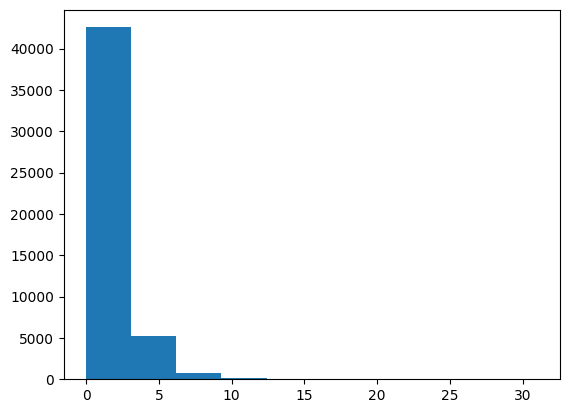

## Summarize Your Results

With your EDA complete, answer the following questions.

1. *Was there anything surprising about your dataset?* 
    - Since this data set captures country and player names across the globe, there are many non-english characters present in the data. I will need to see if that will be a problem in coding/make sure I am able to accurately replicate accurate spelling

  
2. *Do you have any concerns about your dataset?*
    - I am hoping I will be allowed to insert a dataset for country-to-continent so I can do a continental analysis in addition to within the countries themselves. 

3. *Is there anything you want to make note of for the next phase of your analysis, which is cleaning data?* 
    - Why do some countries have former names? Aside from the need to make sure their names are consistent throughout the data, is there insight to be gleaned from countries that encountered socio-political changes and their performance in international soccer? 
    - a LOT of null values in shootouts["first_shoorter"
    - ]

*My questions from Checkpoint 1:*

-	Which international team is the best of all time?
    - Most scores?
    - Most wins? 
    - Largest win differential? 
    - Which team is the best of all time without winning a world cup? (Made it to the final or closest to the final the most and has lost)
-   Which team has never made it out of group? 
-	Which teams have dominated different eras of football?
    - In what measure? Decades?
-	What trends have been present in international football throughout history? (home advantage, total goals scored, etc.) 
    - Is there evidence to a home advantage? If so, is it across the board, or only for certain countries or regions? 
    - Looking at trends and measures of success across tournaments (tends to be regional - africa cup, concacaf, etc.)
-	Who is the greatest goal scorer in international soccer history? 
    - trends across top scorers - country? age? 
-   Locations of games
    - is there a trend in where games are played over time?
    - how do south american teams do in europe or the other way around? 
-   Does war time affect a team? 
-   Continental rankings 
-   Is there more correlation between goals scored or goals scored against in winning? (wil need to think about this more)
-   Trends in friendlies versus actual tournament competitions